# Advanced Search - Larger cover Smaller method


## Load Models


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [40]:
# load the pipelined model
import os
import joblib
from utils.FixedLengthTransformer import FixedLengthTransformer
# load the saved models from the Models directory
model_dir = "Models"
model_files = [f for f in os.listdir(model_dir) if f.endswith('.joblib')]
models = {}
for model_file in model_files:
    model_name = model_file.split('.')[0]
    models[model_name] = joblib.load(os.path.join(model_dir, model_file))
    
# print the model names
print("Available models:")
for model_name in models.keys():
    print(model_name)

selected_models_for_adv = ['Width Aug OHLC_mini_rocket_xgb','Length Normed + Width Aug OHLC_mini_rocket_xgb']
# selected_models_for_adv = ['Width Aug OHLC_mini_rocket_xgb']

Available models:
Width Aug OHLC + traindata Aug_mini_rocket_xgb
Width Aug OHLC_rocket_xgb
Width Aug OHLC_mini_rocket_xgb
Width Aug OHLC + traindata Aug_rocket_xgb
Length Normed + Width Aug OHLC_rocket_xgb
Plane OHLC + traindata Aug_mini_rocket_xgb
Width Aug OHLC + traindata Aug_multi_rocket_xgb
Width Aug OHLC_multi_rocket_xgb
Plane OHLC_rocket_xgb
Plane OHLC + traindata Aug_rocket_xgb
Plane OHLC_mini_rocket_xgb
Plane OHLC_multi_rocket_xgb
Length Normed + Width Aug OHLC_mini_rocket_xgb
Plane OHLC + traindata Aug_multi_rocket_xgb
Length Normed + Width Aug OHLC_multi_rocket_xgb
Length Normed OHLC_multi_rocket_xgb
Length Normed OHLC_mini_rocket_xgb
Length Normed OHLC_rocket_xgb


## Selecting the test sample


In [41]:
import random
# random.seed(69)

test_pattern_segment_wise = pd.read_csv("Datasets/New_pattern_set_data/test_patterns_large_segment_wise.csv")
# convert Seg_Start , Seg_End , Start and End to datetime
test_pattern_segment_wise.loc[:, 'Seg_Start'] = pd.to_datetime(test_pattern_segment_wise['Seg_Start'])
test_pattern_segment_wise.loc[:, 'Seg_End'] = pd.to_datetime(test_pattern_segment_wise['Seg_End'])
test_pattern_segment_wise.loc[:, 'Start'] = pd.to_datetime(test_pattern_segment_wise['Start'])
test_pattern_segment_wise.loc[:, 'End'] = pd.to_datetime(test_pattern_segment_wise['End'])

test_seg_ids_adv = test_pattern_segment_wise['Seg_ID'].unique()
# select random 100 seg ids from the test_seg_ids_adv
test_seg_ids_adv = random.sample(list(test_seg_ids_adv), 100)

selected_test_pattern_segment_wise_adv = test_pattern_segment_wise[test_pattern_segment_wise['Seg_ID'].isin(test_seg_ids_adv)]
# selected_test_pattern_segment_wise_adv = test_pattern_segment_wise.copy()

test_ids_rows_count_sum_adv = test_pattern_segment_wise[test_pattern_segment_wise['Seg_ID'].isin(test_seg_ids_adv)].groupby('Seg_ID').size().sum()
test_ids_rows_count_sum_adv , len(test_seg_ids_adv)

(np.int64(115), 100)

## Advance pattern Locating


In [42]:
# window_size = 20
# win_size_proportion = 5
win_size_proportions = np.round(np.logspace(0, np.log10(20), num=10), 2).tolist()
# Example output: [1.0, 1.58, 2.5, 3.95, 6.25, 9.88, 15.63, 20.0]
padding_proportion = 0.6
stride = 1
probability_threshold = 0.4
# for len norm 
target_len = 30

eps=0.04 # in the dbscan clustering
min_samples=3 # in the dbscan clustering
win_width_proportion=10 # in the dbscan clustering from what amount to divide the width related feature

In [43]:
# from utils.patternLocating import plot_patterns_for_segment

# for id in test_seg_ids_adv:
#     test_seg_id = id
#     plot_patterns_for_segment(test_seg_id , test_pattern_segment_wise)

In [44]:
import sys

from tqdm import tqdm

from utils.formatAndPreprocessNewPatterns import get_reverse_pattern_encoding
from utils.functionalPatternLocateAndPlot import functional_pattern_filter_and_point_recognition
from utils.patternLocating import  get_ohlc_data_segment, parallel_process_sliding_window, prepare_dataset_for_cluster
from utils.functionalPatternLocateAndPlot import plot_pattern_groups_and_finalized_sections
from utils.patternLocating import cluster_windows
from utils.eval import intersection_over_union

located_patterns_and_other_info_dict = {}
window_results_dict = {}
pattern_encoding_reversed = get_reverse_pattern_encoding()
path = 'Datasets/OHLC data'

for model_name in selected_models_for_adv:
    print(f"Selected model: {model_name}")
    model = models[model_name]
    
    located_patterns_and_other_info_list = []
    window_results_list = []

    # for seg_id, group in tqdm(grouped, desc="Processing segments"):
        
    #     test_seg_id = seg_id  
    for test_seg_id in tqdm(test_seg_ids_adv, desc="Processing test segments"):
        # try :
            # plot_patterns_for_segment(test_seg_id    , test_pattern_segment_wise)
            grouped = test_pattern_segment_wise.groupby('Seg_ID')
            # Select a group
            group = grouped.get_group(test_seg_id)

            Seg_Start = group.iloc[0]['Seg_Start']
            Seg_End = group.iloc[0]['Seg_End']
            seg_len = (Seg_End - Seg_Start).days
            
            win_results_for_each_size = []
            located_patterns_and_other_info_for_each_size = []
            cluster_labled_windows_list = []
            
            used_win_sizes = []
            win_iteration = -1
            
            for win_size_proportion in win_size_proportions:

                window_size = seg_len // win_size_proportion
                # print(f"Win size : {window_size}")
                if window_size < 10:
                    window_size = 10
                # elif window_size > 30:
                #     window_size = 30
                    
                # convert to int 
                window_size = int(window_size)
                if window_size in used_win_sizes:
                    continue
                used_win_sizes.append(window_size)
                
                    
                ohlc_data_segment = get_ohlc_data_segment(test_pattern_segment_wise, test_seg_id, path,group) 
                if ohlc_data_segment is None:
                    print("OHLC Data segment is empty")
                    continue   
                
                len_norm=False
                target_len = target_len
                
                # geet th efirst two words of the model_name 
                model_name_parts = model_name.split(' ')
                data_set_type = model_name_parts[0] + ' ' + model_name_parts[1]
                data_set_type
                
                if data_set_type == "Length Normed":
                    len_norm=True
                
                win_results_df = parallel_process_sliding_window(ohlc_data_segment, model, probability_threshold,stride, pattern_encoding_reversed,group,test_seg_id,window_size, padding_proportion, len_norm, target_len)
                
                if win_results_df is None:
                    print("Window results dataframe is empty")
                    continue
                win_results_df['Window_Size'] = window_size
                win_results_for_each_size.append(win_results_df)
                # plot_sliding_steps(win_results_df ,ohlc_data_segment,probability_threshold ,test_seg_id)
                predicted_patterns = prepare_dataset_for_cluster(ohlc_data_segment, win_results_df)
                if predicted_patterns is None:
                    print("Predicted patterns dataframe is empty")
                # print("Predicted Patterns :",predicted_patterns)
                cluster_labled_windows_df , interseced_clusters_df = cluster_windows(predicted_patterns, probability_threshold, window_size)
                if cluster_labled_windows_df is None or interseced_clusters_df is None:
                    print("Clustered windows dataframe is empty")
                    continue
                cluster_labled_windows_df['Cluster'] = cluster_labled_windows_df['Cluster'].astype(int) + win_iteration
                win_iteration += 1
                cluster_labled_windows_list.append(cluster_labled_windows_df)
                located_patterns_and_other_info = functional_pattern_filter_and_point_recognition(interseced_clusters_df)
                if located_patterns_and_other_info is None:
                    print("Located patterns and other info dataframe is empty")
                    continue
                # plot_pattern_groups_and_finalized_sections(located_patterns_and_other_info, cluster_labled_windows_df, test_seg_id)
                located_patterns_and_other_info['Window_Size'] = window_size
                
                located_patterns_and_other_info_for_each_size.append(located_patterns_and_other_info)
                
            located_patterns_and_other_info_for_each_size_df = pd.concat(located_patterns_and_other_info_for_each_size)
            win_results_for_each_size_df = pd.concat(win_results_for_each_size, ignore_index=True)
            window_results_list.append(win_results_for_each_size_df)
            
            # get the set of unique window sizes from located_patterns_and_other_info_for_each_size_df
            unique_window_sizes = located_patterns_and_other_info_for_each_size_df['Window_Size'].unique()
            unique_patterns = located_patterns_and_other_info_for_each_size_df['Chart Pattern'].unique()    
            
            # sort the unique_window_sizes descending order
            unique_window_sizes = np.sort(unique_window_sizes)[::-1]
            
            filtered_loc_pat_and_info_rows_list = []

            for chart_pattern in unique_patterns:    
                located_patterns_and_other_info_for_each_size_df_chart_pattern = located_patterns_and_other_info_for_each_size_df[located_patterns_and_other_info_for_each_size_df['Chart Pattern'] == chart_pattern]
                for win_size in unique_window_sizes:
                    located_patterns_and_other_info_for_each_size_df_win_size_chart_pattern = located_patterns_and_other_info_for_each_size_df_chart_pattern[located_patterns_and_other_info_for_each_size_df_chart_pattern['Window_Size'] == win_size]
                    for idx , row in located_patterns_and_other_info_for_each_size_df_win_size_chart_pattern.iterrows():
                        start_date = row['Calc_Start']
                        end_date = row['Calc_End']
                        is_already_included = False
                        # check if there are any other rows that intersect with the start and end dates with the same chart pattern
                        intersecting_rows = located_patterns_and_other_info_for_each_size_df_chart_pattern[
                                                            (located_patterns_and_other_info_for_each_size_df_chart_pattern['Calc_Start'] <= end_date) &
                                                            (located_patterns_and_other_info_for_each_size_df_chart_pattern['Calc_End'] >= start_date)
                                                        ]
                        is_already_included = False
                        for idx2, row2 in intersecting_rows.iterrows():
                            iou = intersection_over_union(start_date, end_date, row2['Calc_Start'], row2['Calc_End'])

                            if iou > 0.6:
                                # Case 1: Larger window already exists
                                if row2['Window_Size'] > row['Window_Size']:
                                    # Case 1A: But smaller one has significantly higher probability, keep it instead
                                    if (row['Avg_Probability'] - row2['Avg_Probability']) > 0.1:
                                        is_already_included = False
                                        filtered_loc_pat_and_info_rows_list = [
                                            r for r in filtered_loc_pat_and_info_rows_list
                                            if not (r['Chart Pattern'] == row2['Chart Pattern'] and
                                                    r['Window_Size'] == row2['Window_Size'] and
                                                    r['Calc_Start'] == row2['Calc_Start'] and
                                                    r['Calc_End'] == row2['Calc_End'])
                                        ]
                                        break  # Remove large, keep small
                                    else:
                                        is_already_included = True
                                        break  # Keep large, skip small

                                # Case 2: Equal or smaller window exists, possibly overlapping
                                elif row['Window_Size'] >= row2['Window_Size']:
                                    # If current row has significantly better probability, replace existing
                                    if (row['Avg_Probability'] - row2['Avg_Probability']) > 0.1:
                                        filtered_loc_pat_and_info_rows_list = [
                                            r for r in filtered_loc_pat_and_info_rows_list
                                            if not (r['Chart Pattern'] == row2['Chart Pattern'] and
                                                    r['Window_Size'] == row2['Window_Size'] and
                                                    r['Calc_Start'] == row2['Calc_Start'] and
                                                    r['Calc_End'] == row2['Calc_End'])
                                        ]
                                        break

                        if not is_already_included:
                            filtered_loc_pat_and_info_rows_list.append(row)

            
            # convert the filtered_loc_pat_and_info_rows_list to a dataframe
            filtered_loc_pat_and_info_df = pd.DataFrame(filtered_loc_pat_and_info_rows_list)
            located_patterns_and_other_info_list.append(filtered_loc_pat_and_info_df) 
            
            cluster_labled_windows_df_conc = pd.concat(cluster_labled_windows_list)
            # plot_pattern_groups_and_finalized_sections(filtered_loc_pat_and_info_df, cluster_labled_windows_df_conc, test_seg_id)              
        # except:
        #     print("Error in segment ID: ",test_seg_id,"error : ",sys.exc_info()[0])
        #     continue

    located_patterns_and_other_info_final_df = pd.concat(located_patterns_and_other_info_list)
    window_results_all_df = pd.concat(window_results_list)
    
    
    
    located_patterns_and_other_info_dict[model_name] = located_patterns_and_other_info_final_df
    window_results_dict[model_name] = window_results_all_df

    
    

Selected model: Width Aug OHLC_mini_rocket_xgb


Processing test segments:   0%|          | 0/100 [00:00<?, ?it/s][Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:   11.8s
[Parallel(n_jobs=16)]: Done  73 out of  73 | elapsed:   17.6s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.4s
[Parallel(n_jobs=16)]: Done  73 out of  73 | elapsed:    6.7s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.6s
[Parallel(n_jobs=16)]: Done  73 out of  73 | elapsed:    6.5s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.4s
[Parallel(n_jobs=16)]: Done  73 out of  73 | elapsed:    6.4s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done  73 out of  73 | elapsed:    6.9s finished
[Parallel(n_jobs=16)]: Usin

Selected model: Length Normed + Width Aug OHLC_mini_rocket_xgb


Processing test segments:   0%|          | 0/100 [00:00<?, ?it/s][Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done  73 out of  73 | elapsed:    5.7s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done  73 out of  73 | elapsed:    5.5s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.2s
[Parallel(n_jobs=16)]: Done  73 out of  73 | elapsed:    5.6s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.0s
[Parallel(n_jobs=16)]: Done  73 out of  73 | elapsed:    5.8s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=1

Clustered windows dataframe is empty


[Parallel(n_jobs=16)]: Done  44 out of  44 | elapsed:    3.3s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.


Clustered windows dataframe is empty


[Parallel(n_jobs=16)]: Done  44 out of  44 | elapsed:    3.7s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  44 out of  44 | elapsed:    3.2s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  44 out of  44 | elapsed:    3.3s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  44 out of  44 | elapsed:    3.6s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  44 out of  44 | elapsed:    3.3s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  44 out of  44 | elapsed:    3.3s finished
Processing test segments:  18%|█▊        | 18/100 [16:24<1:01:56, 45.33s/it][Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 task

In [45]:
cluster_labled_windows_df , interseced_clusters_df = cluster_windows(predicted_patterns, probability_threshold, window_size)

In [46]:
win_results_for_each_size_df

,Seg_ID,Start,End,Symbol,Chart Pattern,Seg_Start,Seg_End,Probability,Window_Size
0,259,2024-02-12,2024-04-16,AYI,No Pattern,2024-02-10,2024-06-02,0.556144,113
1,259,2024-02-12,2024-04-17,AYI,No Pattern,2024-02-10,2024-06-02,0.473186,113
2,259,2024-02-12,2024-04-18,AYI,No Pattern,2024-02-10,2024-06-02,0.518814,113
3,259,2024-02-12,2024-04-19,AYI,No Pattern,2024-02-10,2024-06-02,0.549150,113
4,259,2024-02-12,2024-04-22,AYI,No Pattern,2024-02-10,2024-06-02,0.463700,113
...,...,...,...,...,...,...,...,...,...
611,259,2024-05-16,2024-05-30,AYI,No Pattern,2024-02-10,2024-06-02,0.973041,10
612,259,2024-05-17,2024-05-31,AYI,No Pattern,2024-02-10,2024-06-02,0.836566,10
613,259,2024-05-20,2024-05-31,AYI,No Pattern,2024-02-10,2024-06-02,0.722591,10
614,259,2024-05-21,2024-05-31,AYI,No Pattern,2024-02-10,2024-06-02,0.864466,10


In [47]:
cluster_labled_windows_df

,Seg_ID,Start,End,Symbol,Chart Pattern,Seg_Start,Seg_End,Probability,Window_Size,Center,Pattern_Start_pos,Pattern_End_pos,Cluster
0,259,2024-02-12,2024-02-15,AYI,No Pattern,2024-02-10,2024-06-02,0.668571,10,2.0,0.0,4.0,0
1,259,2024-02-12,2024-02-16,AYI,No Pattern,2024-02-10,2024-06-02,0.789489,10,2.5,0.0,5.0,0
2,259,2024-02-12,2024-02-20,AYI,No Pattern,2024-02-10,2024-06-02,0.712596,10,3.0,0.0,6.0,0
3,259,2024-02-12,2024-02-21,AYI,No Pattern,2024-02-10,2024-06-02,0.666655,10,3.5,0.0,7.0,0
4,259,2024-02-12,2024-02-22,AYI,No Pattern,2024-02-10,2024-06-02,0.833291,10,4.0,0.0,8.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,259,2024-05-16,2024-05-30,AYI,No Pattern,2024-02-10,2024-06-02,0.973041,10,71.0,66.0,76.0,0
73,259,2024-05-17,2024-05-31,AYI,No Pattern,2024-02-10,2024-06-02,0.836566,10,72.0,67.0,77.0,0
74,259,2024-05-20,2024-05-31,AYI,No Pattern,2024-02-10,2024-06-02,0.722591,10,72.5,68.0,77.0,0
75,259,2024-05-21,2024-05-31,AYI,No Pattern,2024-02-10,2024-06-02,0.864466,10,73.0,69.0,77.0,0


In [48]:
located_patterns_and_other_info_list

[   Seg_ID Symbol         Chart Pattern  Cluster      Start        End  \
 0     286    OMI            No Pattern        0 2020-04-27 2020-08-07   
 2     286    OMI            No Pattern        1 2020-06-16 2020-08-07   
 2     286    OMI            No Pattern        1 2020-07-09 2020-08-07   
 0     286    OMI  Flag, high and tight        0 2020-05-28 2020-08-07   
 0     286    OMI            Double Top        0 2020-07-06 2020-08-06   
 0     286    OMI         Double Bottom        0 2020-06-29 2020-07-30   
 
    Seg_Start    Seg_End  Avg_Probability Calc_Start   Calc_End  Window_Size  
 0 2020-04-26 2020-08-07         0.763268 2020-04-27 2020-08-07          103  
 2 2020-04-26 2020-08-07         0.624176 2020-06-16 2020-08-07           38  
 2 2020-04-26 2020-08-07         0.729772 2020-07-09 2020-08-07           19  
 0 2020-04-26 2020-08-07         0.554985 2020-05-28 2020-08-07           74  
 0 2020-04-26 2020-08-07         0.546136 2020-07-06 2020-08-06           27  
 0 202

## Evaluate


In [49]:
from utils.eval import intersection_over_union , mean_abselute_error
from utils.formatAndPreprocessNewPatterns import get_pattern_list
chart_patterns = get_pattern_list()

In [50]:
test_patterns = pd.read_csv("Datasets/New_pattern_set_data/test_df.csv" )

test_patterns_without_no_pattern = test_patterns[test_patterns['Chart Pattern'] != "No Pattern"].copy()
# rename the Unnamed: 0 column to Instance
test_patterns_without_no_pattern.rename(columns={'Unnamed: 0': 'Instance'}, inplace=True)
# rename the Unnamed: 0 column to Instance
selected_test_pattern_segment_wise_adv.rename(columns={'Unnamed: 0': 'Instance'}, inplace=True)
selected_instances = selected_test_pattern_segment_wise_adv['Instance'].unique()
selected_test_patterns_without_no_pattern = test_patterns_without_no_pattern[test_patterns_without_no_pattern['Instance'].isin(selected_instances)]

/tmp/ipykernel_521650/3363097457.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_pattern_segment_wise_adv.rename(columns={'Unnamed: 0': 'Instance'}, inplace=True)


In [51]:

test_ids_rows_count_sum = selected_test_pattern_segment_wise_adv.groupby('Seg_ID').size().sum()

# per pattern row count in to a dict
pattern_row_count = {}
for pattern in chart_patterns:
    pattern_row_count[pattern] = selected_test_pattern_segment_wise_adv[selected_test_pattern_segment_wise_adv['Chart Pattern'] == pattern].shape[0]
    
pattern_row_count

{'Double Top': 43,
 'Double Bottom': 37,
 'Triangle, symmetrical': 9,
 'Head-and-shoulders top': 10,
 'Head-and-shoulders bottom': 7,
 'Flag, high and tight': 9,
 'No Pattern': 0}

In [52]:
located_patterns_and_other_info_dict_copy = located_patterns_and_other_info_dict.copy()

In [53]:
# get only the rows with Avg_Probability > 0.6 
located_patterns_and_other_info_dict = {
    model_name: df[~df['Avg_Probability'].isna() & (df['Avg_Probability'] > 0.0)]
    for model_name, df in located_patterns_and_other_info_dict.items()
}   

In [54]:
located_patterns_and_other_info_dict 


{'Width Aug OHLC_mini_rocket_xgb':     Seg_ID Symbol              Chart Pattern  Cluster      Start        End  \
 0      286    OMI       Flag, high and tight        0 2020-04-27 2020-08-07   
 2      286    OMI       Flag, high and tight        1 2020-06-08 2020-08-07   
 3      286    OMI       Flag, high and tight        1 2020-05-21 2020-07-01   
 4      286    OMI       Flag, high and tight        0 2020-04-27 2020-05-15   
 5      286    OMI       Flag, high and tight        1 2020-05-13 2020-05-29   
 ..     ...    ...                        ...      ...        ...        ...   
 3      259    AYI                 No Pattern        0 2024-02-12 2024-02-20   
 4      259    AYI                 No Pattern        1 2024-02-20 2024-03-08   
 5      259    AYI                 No Pattern        2 2024-03-07 2024-03-25   
 0      259    AYI              Double Bottom        0 2024-02-12 2024-02-29   
 5      259    AYI  Head-and-shoulders bottom        0 2024-04-11 2024-05-09   
 
    

In [55]:
from tqdm import tqdm
import pandas as pd
from utils.eval import get_model_eval_res

model_eval_results_dict = get_model_eval_res(located_patterns_and_other_info_dict,window_results_dict,selected_models_for_adv,selected_test_patterns_without_no_pattern)
model_eval_results_dict


 Selected model: Width Aug OHLC_mini_rocket_xgb
Processing row 63/115

Processing row 1061/115
 Selected model: Length Normed + Width Aug OHLC_mini_rocket_xgb
Processing row 1061/115

{'Width Aug OHLC_mini_rocket_xgb': {'number_of_properly_located_patterns': {'Double Top': 34,
   'Flag, high and tight': 8,
   'Double Bottom': 29,
   'Triangle, symmetrical': 9,
   'Head-and-shoulders bottom': 2,
   'Head-and-shoulders top': 9},
  'iou_for_each_properly_detected_pattern': {'Double Top': 18.581915901711927,
   'Flag, high and tight': 4.356945658602678,
   'Double Bottom': 14.87164248977425,
   'Triangle, symmetrical': 4.478648621549993,
   'Head-and-shoulders bottom': 1.2792452830188679,
   'Head-and-shoulders top': 4.400052182615019},
  'mae_for_each_properly_detected_pattern': {'Double Top': 280.0,
   'Flag, high and tight': 128.5,
   'Double Bottom': 221.0,
   'Triangle, symmetrical': 140.0,
   'Head-and-shoulders bottom': 15.5,
   'Head-and-shoulders top': 176.5}},
 'Length Normed + Width Aug OHLC_mini_rocket_xgb': {'number_of_properly_located_patterns': {'Double Top': 16,
   'Double Bottom': 21,
   'Triangle, symmetrical': 5,
   'Head-and-shoulders bottom': 1,
   


==================== Model: Width Aug OHLC_mini_rocket_xgb ====================
Overall Recall: 0.7913
Overall Precision: 0.0329
Overall F1 Score: 0.0605
Overall Mean Absolute Error: 10.5659
Overall Mean Intersection over Union: 0.5271

==================== Model: Length Normed + Width Aug OHLC_mini_rocket_xgb ====================
Overall Recall: 0.4435
Overall Precision: 0.0491
Overall F1 Score: 0.0680
Overall Mean Absolute Error: 12.4412
Overall Mean Intersection over Union: 0.4866

--- Comprehensive Model Comparison ---


/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/eval.py:341: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.88])  # Adjusted rect to account for title and legend


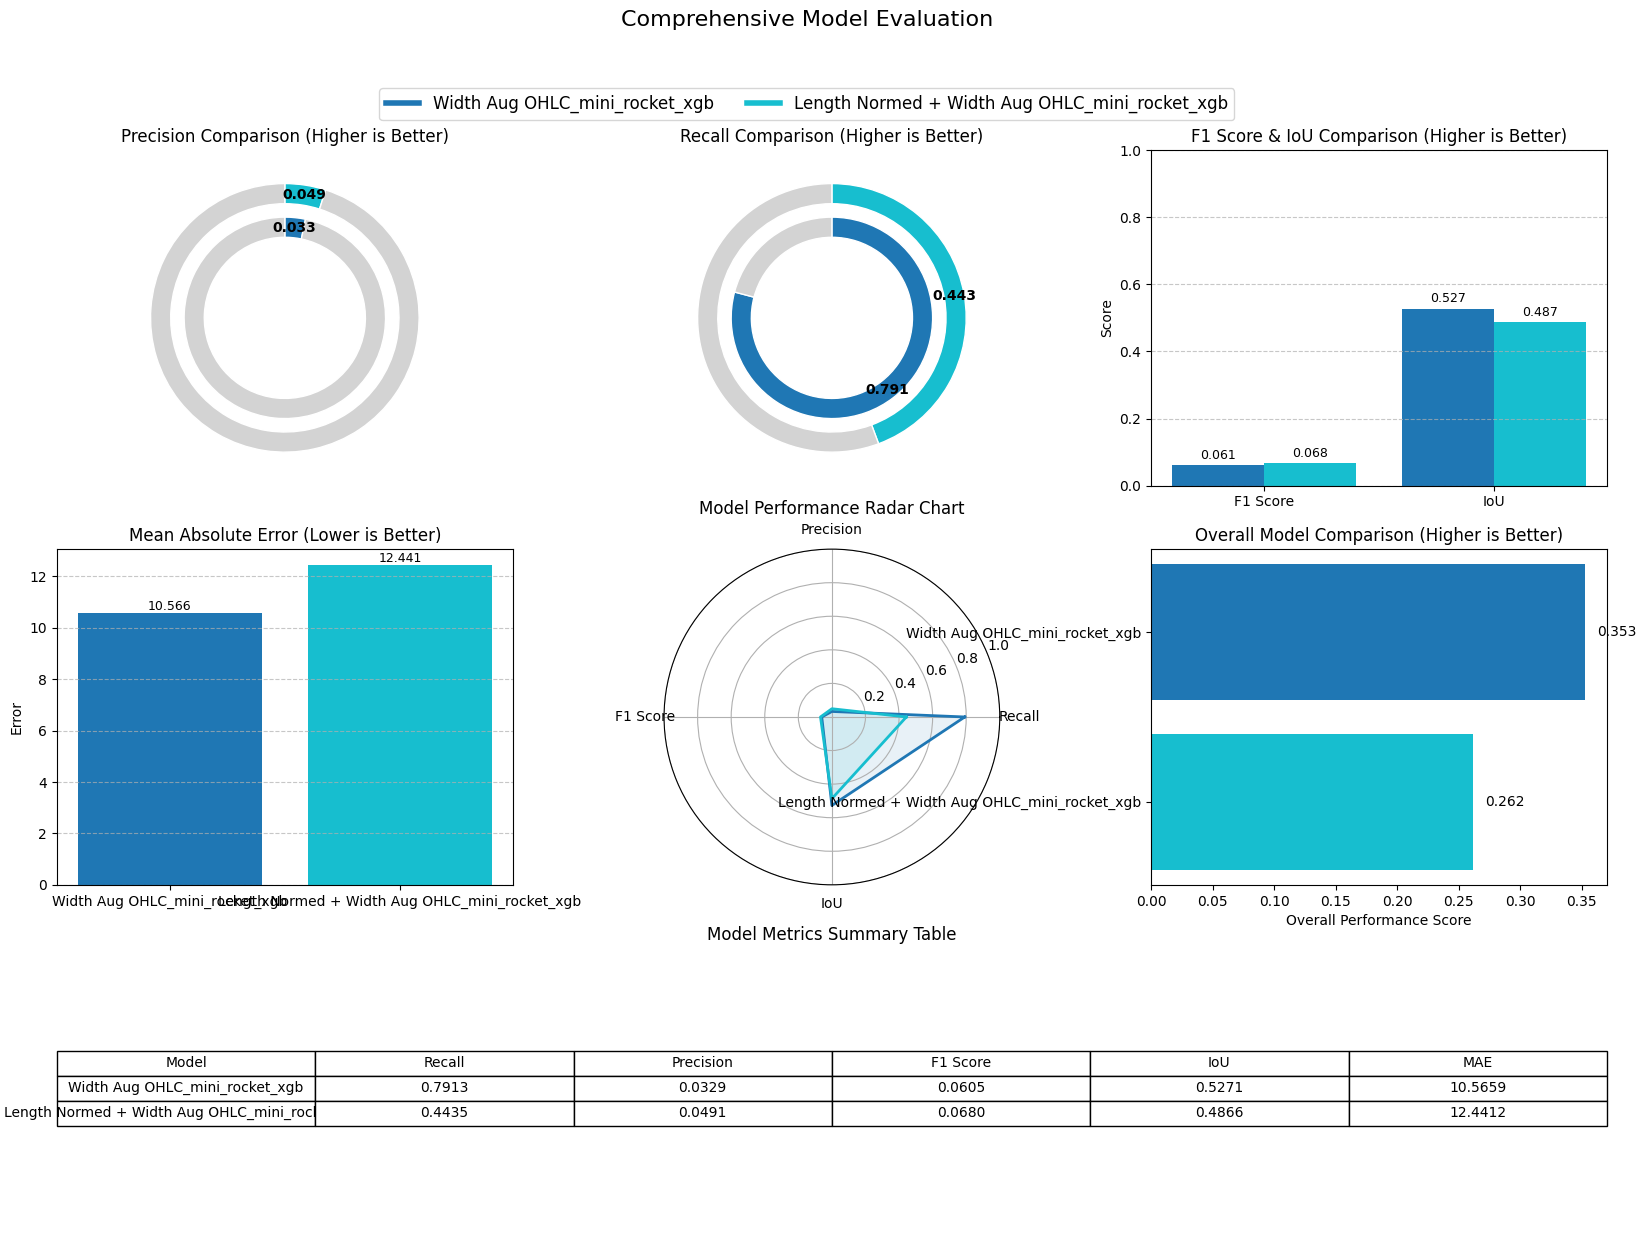

In [56]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from utils.eval import evaluate_all_models

all_metrics = evaluate_all_models(model_eval_results_dict, pattern_row_count, test_patterns, located_patterns_and_other_info_dict)
figure = all_metrics[1]